# Algoritmo Genético Simple — Ejercicio

---
## 1. Importación de librerías

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

np.random.seed(42)
print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


---
## 2. Función Objetivo

Se construye una **spline cúbica** a partir de los 8 valores exactos de la tabla de referencia del enunciado (generados con Lind=3 bits). Esto garantiza que el AG evalúe una función continua que pasa **exactamente** por todos los puntos de la tabla.

In [18]:
# Tabla de referencia del enunciado (Lind=3 bits → 8 puntos)
x_ref = np.array([0.000, 0.125, 0.250, 0.375, 0.500, 0.625, 0.750, 0.875])
y_ref = np.array([1.285, 1.629, 0.335, 0.792, 2.000, 3.990, 3.104, 1.093])

# Spline cúbica que reproduce exactamente la tabla
f_spline = CubicSpline(x_ref, y_ref)

def objfun_1var(fenotipo):
    """Evalúa f(x) para cada individuo. fenotipo: (Nind, 1)"""
    return f_spline(fenotipo[:, 0]).reshape(-1, 1)

# Verificar contra tabla
print(f"{'#':>3}  {'Código':>6}  {'x':>7}  {'F(x)':>8}  {'Esperado':>9}  {'OK?':>5}")
print("-" * 50)
for i, (xi, yi) in enumerate(zip(x_ref, y_ref)):
    fval = float(f_spline(xi))
    codigo = format(i, '03b')
    ok = "✓" if abs(fval - yi) < 1e-6 else "✗"
    print(f"{i:>3}  {codigo:>6}  {xi:>7.3f}  {fval:>8.4f}  {yi:>9.3f}  {ok:>5}")

  #  Código        x      F(x)   Esperado    OK?
--------------------------------------------------
  0     000    0.000    1.2850      1.285      ✓
  1     001    0.125    1.6290      1.629      ✓
  2     010    0.250    0.3350      0.335      ✓
  3     011    0.375    0.7920      0.792      ✓
  4     100    0.500    2.0000      2.000      ✓
  5     101    0.625    3.9900      3.990      ✓
  6     110    0.750    3.1040      3.104      ✓
  7     111    0.875    1.0930      1.093      ✓


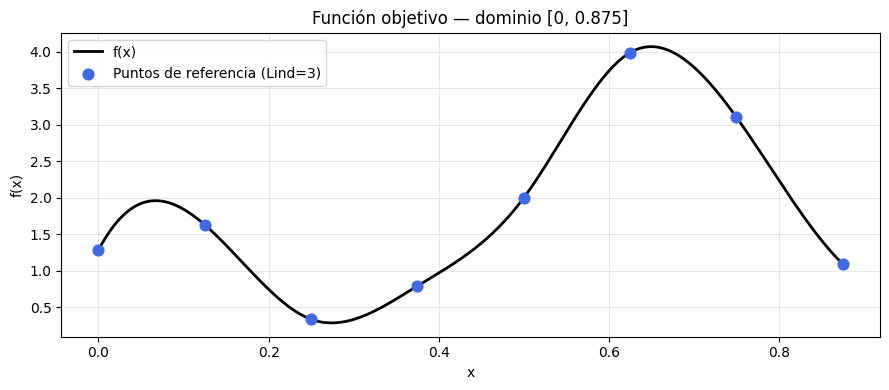

In [19]:
# Gráfica de la función objetivo
x_plot = np.linspace(0, 0.875, 500)
y_plot = f_spline(x_plot)

plt.figure(figsize=(9, 4))
plt.plot(x_plot, y_plot, 'k-', linewidth=2, label='f(x)')
plt.scatter(x_ref, y_ref, color='royalblue', zorder=5, s=60, label='Puntos de referencia (Lind=3)')
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Función objetivo — dominio [0, 0.875]')
plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()

---
## 3. Parámetros del Algoritmo Genético

In [20]:
# ── Parámetros del enunciado ────────────────────────────────────────────────────
Nind   = 5            # Tamaño de la población (fijo en todas las generaciones)
Lind   = 20           # Longitud del cromosoma binario
Pc     = 0.70         # Probabilidad de cruzamiento
Pm     = 1/15         # Probabilidad de mutación
Maxgen = 100          # Número de generaciones
Nvar   = 1            # Una sola variable independiente: x

# Rango: 1 variable x en [0, 0.875]
# rango[0,0]=límite inferior, rango[1,0]=límite superior
rango = np.array([[0.0],
                  [0.875]])

print(f"Nind={Nind} | Lind={Lind} | Pc={Pc:.2f} | Pm={Pm:.4f} (~1/15) | Maxgen={Maxgen}")
print(f"Rango x: [{rango[0,0]}, {rango[1,0]}]")
print()
# Verificar precision: con Lind=20 bits y 1 variable
precision_step = (rango[1,0] - rango[0,0]) / (2**Lind - 1)
print(f"Precisión con Lind={Lind}: step = {precision_step:.8f}  (< 0.001 = 3 decimales ✓)")

Nind=5 | Lind=20 | Pc=0.70 | Pm=0.0667 (~1/15) | Maxgen=100
Rango x: [0.0, 0.875]

Precisión con Lind=20: step = 0.00000083  (< 0.001 = 3 decimales ✓)


---
## 4. Funciones del Algoritmo Genético

In [21]:
def creapob(Nind, Lind):
    """Genera la población inicial aleatoria en binario. Matriz (Nind x Lind)."""
    return np.random.randint(0, 2, size=(Nind, Lind))

In [22]:
def decodifica(genotipo, rango):
    """
    Decodifica cromosomas binarios al dominio real.
    x_i = l_inf + decimal(bits) * (l_sup - l_inf) / (2^Lvar - 1)
    """
    Nvar = rango.shape[1]
    Nind, Lind = genotipo.shape
    Lvar = Lind // Nvar
    potencias = 2 ** np.arange(Lvar)
    fenotipo = np.zeros((Nind, Nvar))

    for i in range(Nind):
        for j in range(Nvar):
            fenotipo[i, j] = np.sum(potencias * genotipo[i, (j*Lvar):(j*Lvar + Lvar)])

    for j in range(Nvar):
        fenotipo[:, j] = (rango[0, j]
                          + ((rango[1, j] - rango[0, j]) / (2**Lvar - 1))
                          * fenotipo[:, j])
    return fenotipo

In [23]:
def rankeo(objv, direccion):
    """
    Aptitud por rankeo lineal.
    direccion=1 → maximizar
    """
    SP = 2
    Nind, _ = objv.shape
    aptitud = np.zeros((Nind, 1))

    nuevo_objv = np.sort(objv if direccion == 1 else -objv, axis=0)
    apt = 2 - SP + 2*(SP-1)*(np.arange(Nind) / (Nind-1))
    posori = np.argsort(nuevo_objv, axis=0)
    aptitud[posori, 0] = apt.reshape(-1, 1)

    return aptitud

In [24]:
def ruleta(genotipo, fenotipo, aptitud):
    """Selección proporcional por ruleta."""
    Nind, _ = aptitud.shape
    total = np.sum(aptitud)
    acumulada = np.cumsum(aptitud / total)
    idx = np.zeros(Nind, dtype=int)

    for i in range(Nind):
        r = np.random.rand()
        idx[i] = np.where(acumulada >= r)[0][0]

    return genotipo[idx, :]

In [25]:
def xunpunto(nuevo_gen, Pc):
    """Cruzamiento de un punto con probabilidad Pc."""
    Nind, Lind = nuevo_gen.shape
    aux_gen = nuevo_gen.copy().astype(float)

    for i in range(0, Nind - 1, 2):
        if np.random.rand() <= Pc:
            corte = np.random.randint(1, Lind)  # punto de corte en [1, Lind-1]
            aux_gen[i, :]     = np.concatenate((nuevo_gen[i, :corte],     nuevo_gen[i+1, corte:]))
            aux_gen[i+1, :]   = np.concatenate((nuevo_gen[i+1, :corte],   nuevo_gen[i,   corte:]))

    if Nind % 2 == 1:           # si la población es impar, el último pasa sin cambio
        aux_gen[-1, :] = nuevo_gen[-1, :]

    return aux_gen

In [26]:
def muta(nuevo_gen, Pm):
    """Mutación uniforme bit a bit con probabilidad Pm."""
    mascara = np.random.rand(*nuevo_gen.shape) <= Pm
    return np.logical_xor(nuevo_gen, mascara).astype(int)

print("Todas las funciones definidas correctamente ✓")

Todas las funciones definidas correctamente ✓


---
## 5. Inicialización de la Población

Se crea la población inicial: una matriz **(Nind × Lind)** = **(5 × 20)** con valores binarios aleatorios.

In [27]:
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)
objv     = objfun_1var(fenotipo)

# Arreglos para guardar historial
Mejor           = np.full((Maxgen, 1), np.nan)
Mejor_cromosoma = np.zeros((Maxgen, Lind))

print("Población inicial (Generación 0):")
print(f"{'Ind':>4}  {'x':>10}  {'f(x)':>8}")
print("-" * 28)
for i in range(Nind):
    print(f"{i:>4}  {fenotipo[i,0]:>10.6f}  {objv[i,0]:>8.4f}")
print(f"\nMejor valor inicial: f(x) = {objv.max():.6f}")

Población inicial (Generación 0):
 Ind           x      f(x)
----------------------------
   0    0.396940    0.9470
   1    0.079465    1.9427
   2    0.091321    1.8947
   3    0.639027    4.0565
   4    0.437349    1.2605

Mejor valor inicial: f(x) = 4.056503


---
## 6. Ciclo Evolutivo (100 generaciones)

In [28]:
generaciones = 1

while generaciones < Maxgen:

    # 1. Aptitud por rankeo (maximizar)
    aptitud = rankeo(objv, 1)

    # 2. Selección proporcional (ruleta)
    nuevo_gen = ruleta(genotipo, fenotipo, aptitud)

    # 3. Cruzamiento de un punto
    nuevo_gen = xunpunto(nuevo_gen, Pc)

    # 4. Mutación uniforme
    nuevo_gen = muta(nuevo_gen, Pm)

    # 5. Decodificar y evaluar nueva población
    nuevo_feno = decodifica(nuevo_gen, rango)
    nuevo_objv = objfun_1var(nuevo_feno)

    # 6. Reemplazar población
    genotipo = nuevo_gen
    fenotipo = nuevo_feno
    objv     = nuevo_objv

    # 7. Guardar mejor de esta generación
    idx = np.argmax(objv)
    Mejor[generaciones]              = objv[idx]
    Mejor_cromosoma[generaciones, :] = genotipo[idx, :]

    generaciones += 1

print("Ciclo evolutivo completado ✓")

Ciclo evolutivo completado ✓


---
## 7. Resultado Final

In [29]:
mejor_gen = int(np.nanargmax(Mejor))
mejor_val = float(Mejor[mejor_gen, 0])
mejor_x   = float(decodifica(Mejor_cromosoma[mejor_gen, :].reshape(1, -1), rango)[0, 0])

print("═" * 40)
print("  RESULTADO DEL ALGORITMO GENÉTICO")
print("═" * 40)
print(f"  Mejor generación : {mejor_gen}")
print(f"  x óptimo         : {mejor_x:.6f}")
print(f"  Mejor f(x)       : {mejor_val:.6f}")
print("═" * 40)
print()
print("Tabla de referencia del enunciado:")
print(f"  Máximo esperado  : f(0.625) = 3.9900")
print(f"  Diferencia AG    : {abs(mejor_val - 3.99):.6f}")

════════════════════════════════════════
  RESULTADO DEL ALGORITMO GENÉTICO
════════════════════════════════════════
  Mejor generación : 72
  x óptimo         : 0.649530
  Mejor f(x)       : 4.071091
════════════════════════════════════════

Tabla de referencia del enunciado:
  Máximo esperado  : f(0.625) = 3.9900
  Diferencia AG    : 0.081091


---
## 8. Gráfica de la Función con el Óptimo Encontrado

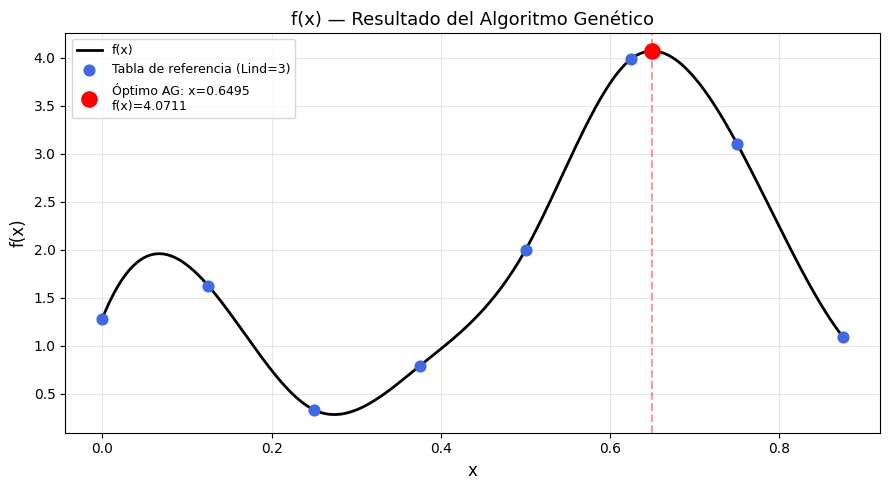

In [30]:
x_plot = np.linspace(0, 0.875, 500)
y_plot = f_spline(x_plot)

plt.figure(figsize=(9, 5))
plt.plot(x_plot, y_plot, 'k-', linewidth=2, label='f(x)')
plt.scatter(x_ref, y_ref, color='royalblue', zorder=5, s=60, label='Tabla de referencia (Lind=3)')
plt.scatter(mejor_x, mejor_val, color='red', s=120, zorder=6,
            label=f'Óptimo AG: x={mejor_x:.4f}\nf(x)={mejor_val:.4f}')
plt.axvline(x=mejor_x, color='red', linestyle='--', alpha=0.4)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('f(x) — Resultado del Algoritmo Genético', fontsize=13)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Gráfica de Convergencia

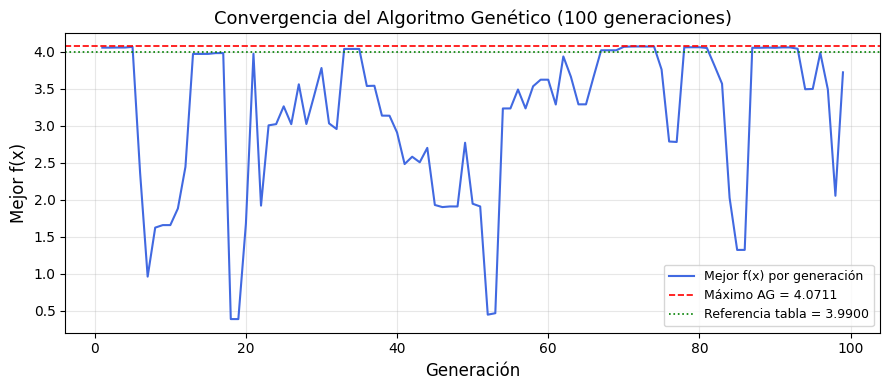

In [31]:
gens_validas = np.where(~np.isnan(Mejor[:, 0]))[0]

plt.figure(figsize=(9, 4))
plt.plot(gens_validas, Mejor[gens_validas, 0], color='royalblue', linewidth=1.5,
         label='Mejor f(x) por generación')
plt.axhline(y=mejor_val, color='red', linestyle='--', linewidth=1.2,
            label=f'Máximo AG = {mejor_val:.4f}')
plt.axhline(y=3.99, color='green', linestyle=':', linewidth=1.2,
            label='Referencia tabla = 3.9900')
plt.xlabel('Generación', fontsize=12)
plt.ylabel('Mejor f(x)', fontsize=12)
plt.title('Convergencia del Algoritmo Genético (100 generaciones)', fontsize=13)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 10. Comparación: AG vs Búsqueda Exhaustiva

In [32]:
# Búsqueda exhaustiva en malla fina
x_bf   = np.linspace(0, 0.875, 100_000)
y_bf   = f_spline(x_bf)
idx_bf = np.argmax(y_bf)
x_opt_bf = x_bf[idx_bf]
f_opt_bf = y_bf[idx_bf]

print("═" * 55)
print("   COMPARACIÓN: AG vs BÚSQUEDA EXHAUSTIVA")
print("═" * 55)
print(f"  {'Método':<30} {'x óptimo':>10}  {'f(x)':>8}")
print("─" * 55)
print(f"  {'Algoritmo Genético':<30} {mejor_x:>10.6f}  {mejor_val:>8.6f}")
print(f"  {'Búsqueda exhaustiva':<30} {x_opt_bf:>10.6f}  {f_opt_bf:>8.6f}")
print(f"  {'Tabla referencia (x=0.625)':<30} {'0.625000':>10}  {'3.990000':>8}")
print("─" * 55)
print(f"  Diferencia absoluta: {abs(mejor_val - f_opt_bf):.6f}")
print(f"  Eficiencia del AG  : {(mejor_val / f_opt_bf)*100:.2f}%")
print("═" * 55)

═══════════════════════════════════════════════════════
   COMPARACIÓN: AG vs BÚSQUEDA EXHAUSTIVA
═══════════════════════════════════════════════════════
  Método                           x óptimo      f(x)
───────────────────────────────────────────────────────
  Algoritmo Genético               0.649530  4.071091
  Búsqueda exhaustiva              0.649650  4.071093
  Tabla referencia (x=0.625)       0.625000  3.990000
───────────────────────────────────────────────────────
  Diferencia absoluta: 0.000002
  Eficiencia del AG  : 100.00%
═══════════════════════════════════════════════════════
